In [1]:
import os, sys
from pathlib import Path
try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        os.chdir(os.path.dirname(os.path.dirname(notebook_path)))
except Exception:
    pass
sys.path.insert(0, 'utils')
print('cwd:', os.getcwd())

cwd: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import config

pd.set_option('display.float_format', '{:,.0f}'.format)

LAB_FOLDER   = Path(config.LAB_EXP_FOLDER)
TRAIN_JL     = config.TRAINING_DATA_PATH
RESULT_JL    = config.TRAINING_RESULT_PATH


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



## Parameters
Change these to switch dataset / model.

In [ ]:
# ── Dataset ───────────────────────────────────────────────────────────────────
FOLDER = 'AMCA_qdPCR'          # experiment sub-folder; set to None to scan all

# ── Misclassification section ─────────────────────────────────────────────────
MODEL_KEY      = 'cnn_gru_dual'   # key as in config.MODEL_KEY_MAP / results dict
OUTLIER_FILTER = None             # None = baseline; or e.g. 'lstm_ae_pw_ds1_label_elbow'
N_SPLITS       = 5               # must match the n_splits used during training

# ── Plot aesthetics ───────────────────────────────────────────────────────────
CURVE_ALPHA    = 0.04   # individual curve transparency in grid
MAX_CONC_COLS  = 7      # cap grid columns; concentrations are binned if more
FIG_DPI        = 110

# ── Colour map for targets (consistent across all sections) ──────────────────
# Filled in at load time once we know the unique labels.
TARGET_COLORS  = {}     # {label_str: colour}

---
## Data loading helpers

In [16]:
def _conc_label(v):
    """Human-readable concentration string: 1_000_000 → '1M', 10_000 → '10K', etc."""
    if v >= 1e6:  return f'{v/1e6:.4g}M'
    if v >= 1e3:  return f'{v/1e3:.4g}K'
    return f'{v:.4g}'


def list_available_folders(lab_folder=LAB_FOLDER, train_jl=TRAIN_JL):
    """Return DataFrame of folders that have non-None concentration data."""
    rows = []
    for p in sorted(Path(lab_folder).iterdir()):
        if not p.is_dir(): continue
        jl_path = p / train_jl
        if not jl_path.exists(): continue
        try:
            d = joblib.load(jl_path)
        except Exception:
            continue
        c = d.get('concentration')
        if c is None: continue
        c = np.array(c, dtype=float)
        if np.all(np.isnan(c)): continue
        labels = d['well_labels']
        rows.append({
            'folder': p.name,
            'n_samples': len(labels),
            'n_targets': len(np.unique(labels)),
            'n_conc': len(np.unique(c[~np.isnan(c)])),
            'conc_range': f"{_conc_label(np.nanmin(c))} – {_conc_label(np.nanmax(c))}",
        })
    return pd.DataFrame(rows)


def load_folder_data(folder, lab_folder=LAB_FOLDER, train_jl=TRAIN_JL):
    """Load ori_curves, labels, concentration for *folder*.
    
    Returns dict with keys:
        ori_curves    : (N, T) float ndarray
        labels        : (N,)  str ndarray
        concentration : (N,)  float ndarray  (NaN where missing)
        timestamps    : (T,)  float ndarray or None
        folder        : str
    """
    p = Path(lab_folder) / folder / train_jl
    d = joblib.load(p)

    curves_store = d['curves']
    ori = curves_store['ori_curves'] if isinstance(curves_store, dict) else curves_store

    labels = np.array(d['well_labels'])
    raw_conc = d.get('concentration')
    conc = np.array(raw_conc if raw_conc is not None else [np.nan] * len(labels), dtype=float)
    ts     = np.array(d.get('timestamps', None))
    if ts is not None and ts.ndim > 1: ts = ts[0]   # some fmts store per-curve

    kf_list = d.get('kinetic_features')
    kf = kf_list[0].reset_index(drop=True) if kf_list else None  # index 0 = ori_curves features

    return dict(ori_curves=ori, labels=labels, concentration=conc,
                timestamps=ts, kinetic_features=kf, folder=folder)



def _assign_target_colors(labels):
    """Populate global TARGET_COLORS from tab10, stable across plots in a session."""
    global TARGET_COLORS
    unique = sorted(np.unique(labels))
    palette = plt.get_cmap('tab10').colors
    TARGET_COLORS = {lbl: palette[i % 10] for i, lbl in enumerate(unique)}


# ── Quick overview ────────────────────────────────────────────────────────────
print(list_available_folders().to_string(index=False))

     folder  n_samples  n_targets  n_conc conc_range
  ACA_qdPCR      16188          3       6    5K – 1M
AMCA_qdLAMP      54186          5       7   2K – 10M
 AMCA_qdPCR      58598          9       5   1K – 10M


---
## Load selected folder

In [17]:
data  = load_folder_data(FOLDER)
kf = data.get('kinetic_features')   # (N, n_features) DataFrame or None
ori   = data['ori_curves']       # (N, T)
labels = data['labels']           # (N,) str
conc   = data['concentration']    # (N,) float
ts     = data['timestamps']       # (T,) or None
t_axis = ts if ts is not None else np.arange(ori.shape[1])

_assign_target_colors(labels)

valid_mask = ~np.isnan(conc)
print(f"{FOLDER}: {ori.shape[0]} curves, {len(TARGET_COLORS)} targets, "
      f"{len(np.unique(conc[valid_mask]))} conc levels, T={ori.shape[1]}")
print(f"Concentration range: {np.nanmin(conc):.4g} – {np.nanmax(conc):.4g}")

AMCA_qdPCR: 58598 curves, 9 targets, 5 conc levels, T=45
Concentration range: 1000 – 1e+07


---
## Section 1 · Data distribution

In [35]:
def plot_distribution_table(labels, concentration, title=''):
    """Cross-tabulation of sample counts: rows = target, columns = concentration.
    Returns the styled DataFrame.
    """
    valid = ~np.isnan(concentration)
    lbl_v = labels[valid]
    con_v = concentration[valid]

    unique_conc = sorted(np.unique(con_v))
    unique_tgt  = sorted(np.unique(lbl_v))

    df = pd.DataFrame(index=unique_tgt, columns=[_conc_label(c) for c in unique_conc], dtype=int)
    for tgt in unique_tgt:
        for c in unique_conc:
            df.loc[tgt, _conc_label(c)] = int(np.sum((lbl_v == tgt) & (con_v == c)))

    df['TOTAL'] = df.sum(axis=1)
    df.loc['TOTAL'] = df.sum(axis=0)
    df = df.astype(int)

    if title:
        print(f"\nSample counts — {title}")
    styled = (df.style.background_gradient(cmap='Blues', subset=pd.IndexSlice[unique_tgt, [_conc_label(c) for c in unique_conc]]).format('{:d}'))

    return styled


plot_distribution_table(labels, conc, FOLDER)


Sample counts — AMCA_qdPCR


,1K,10K,100K,1M,10M,TOTAL
mcr-1,69,588,2260,2310,1540,6767
mcr-2,101,640,2300,2308,1540,6889
mcr-3,42,297,2001,2303,1516,6159
mcr-4,75,420,2177,2309,1539,6520
mcr-5,87,479,2060,2260,1538,6424
mcr-6,53,385,2159,2310,1540,6447
mcr-7,57,184,1876,2263,1539,5919
mcr-8,75,699,2260,2310,1540,6884
mcr-9,0,554,2212,2283,1540,6589
TOTAL,559,4246,19305,20656,13832,58598


---
## Section 2 · Curve grid (row = target, column = concentration)

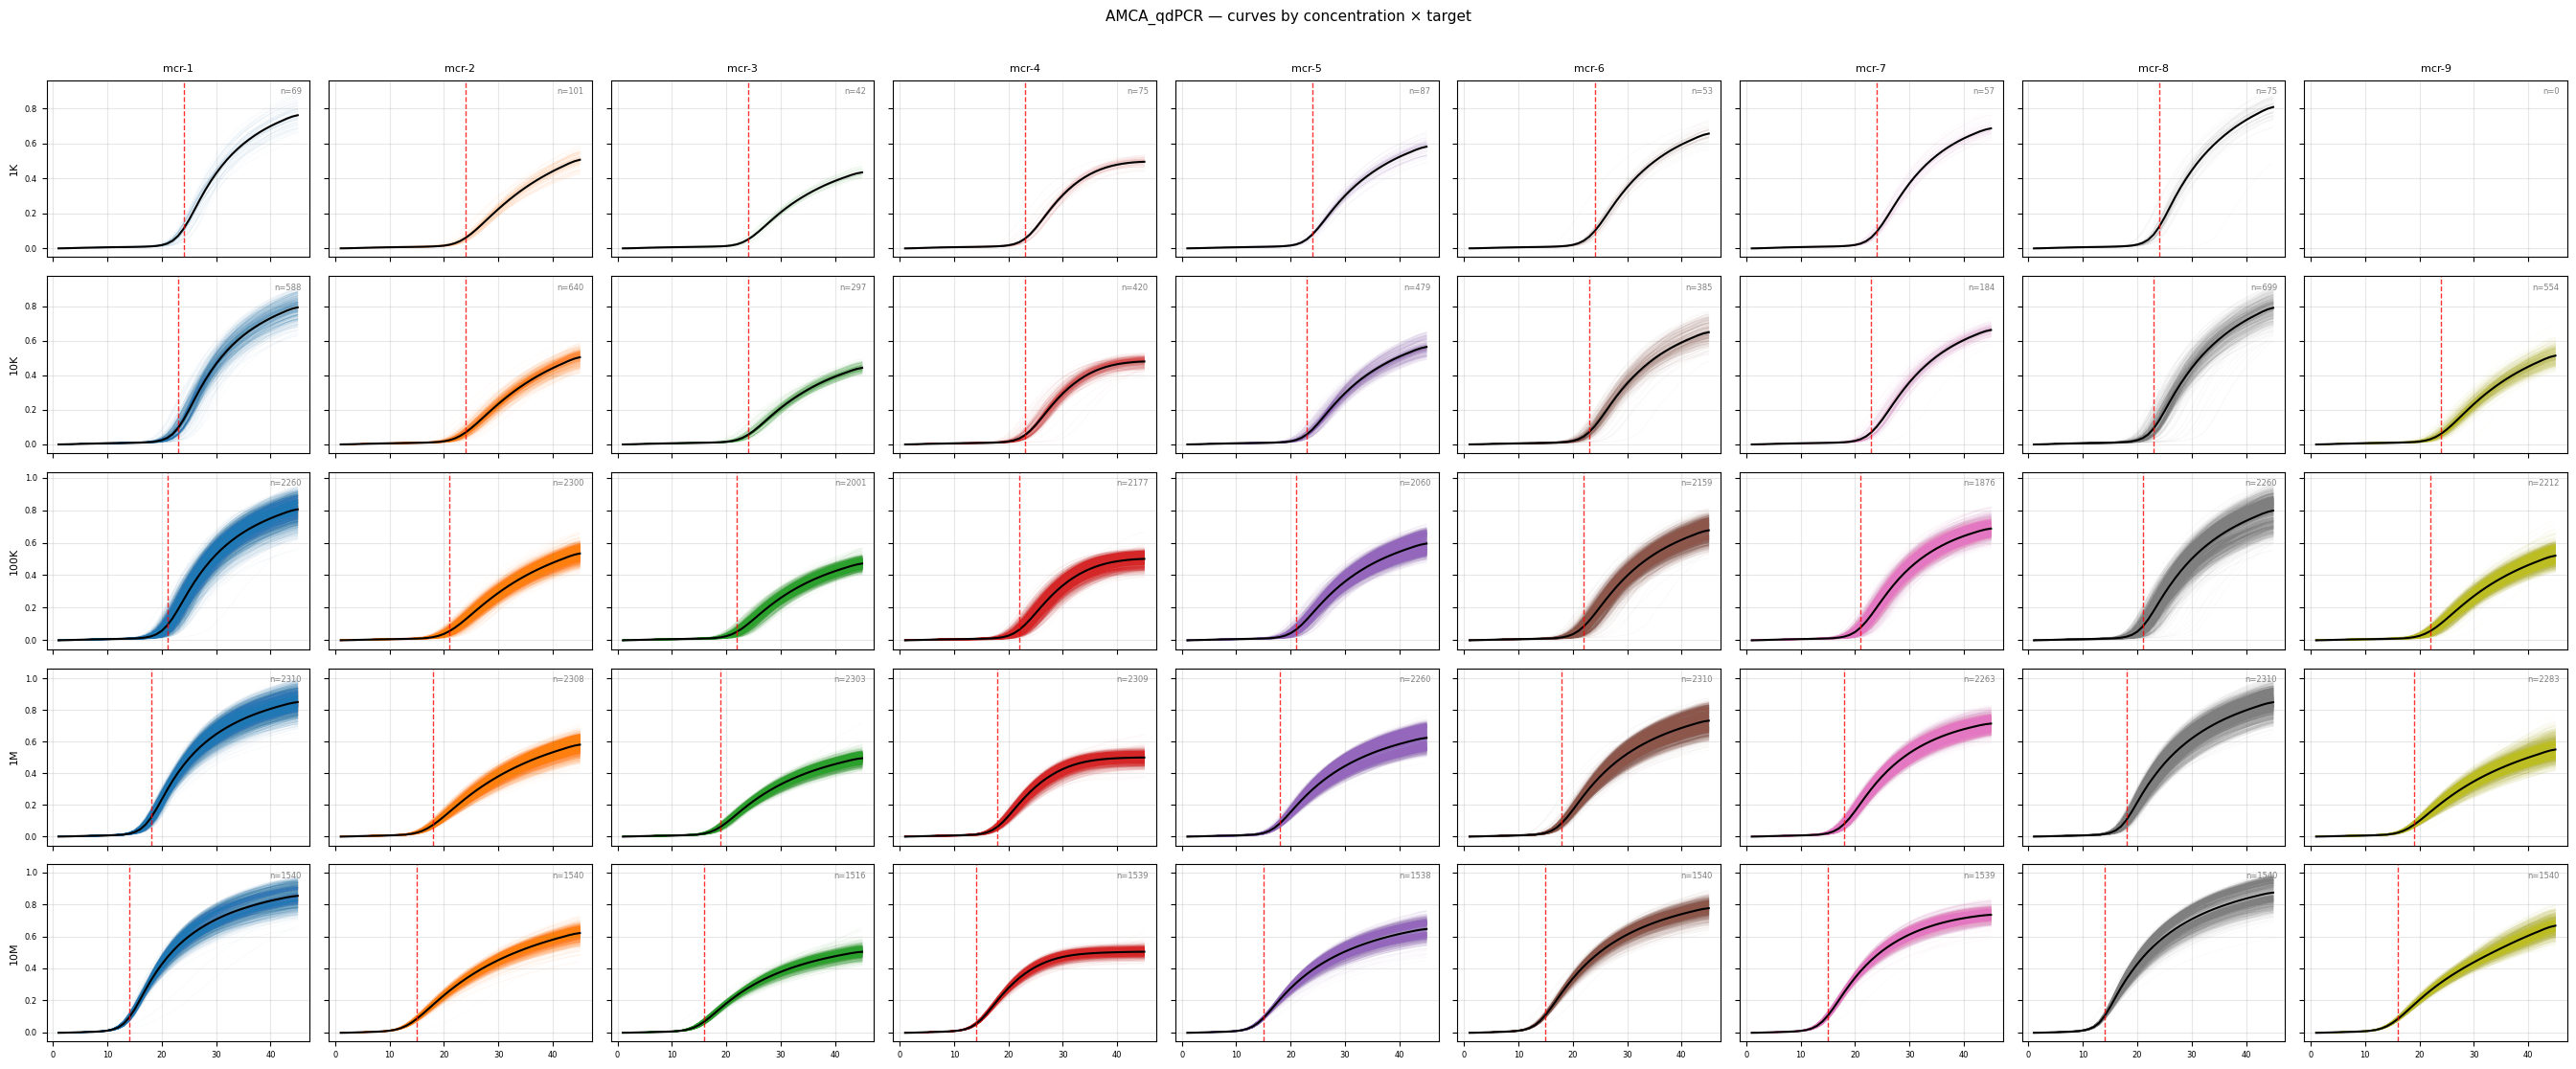

In [19]:
def plot_curve_grid(ori, labels, concentration, t_axis=None,
                    title='', max_conc_cols=MAX_CONC_COLS,
                    curve_alpha=CURVE_ALPHA, figsize_per_cell=(3.0, 2.2)):
    """Row = concentration, column = target.
    Each cell: all individual curves (low alpha) + mean in black (alpha=1)
    + vertical line at TTP (first point where mean >= 10% of its max).
    """
    valid = ~np.isnan(concentration)
    ori_v, lbl_v, con_v = ori[valid], labels[valid], concentration[valid]
    if t_axis is None:
        t_axis = np.arange(ori.shape[1])

    unique_tgt  = sorted(np.unique(lbl_v))
    unique_conc = sorted(np.unique(con_v))

    n_rows, n_cols = len(unique_conc), len(unique_tgt)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_cell[0] * n_cols, figsize_per_cell[1] * n_rows),
        sharex=True, sharey='row',
    )
    if n_rows == 1: axes = [axes]
    if n_cols == 1: axes = [[ax] for ax in axes]

    for r, c_val in enumerate(unique_conc):
        for c_idx, tgt in enumerate(unique_tgt):
            ax = axes[r][c_idx]
            mask = (lbl_v == tgt) & (con_v == c_val)
            subset = ori_v[mask]

            if len(subset) > 0:
                ax.plot(t_axis, subset.T, color=TARGET_COLORS.get(tgt, 'steelblue'),
                        alpha=curve_alpha, linewidth=0.5, rasterized=True)
                mean_curve = subset.mean(axis=0)
                ax.plot(t_axis, mean_curve, color='black', linewidth=1.5, alpha=1.0)

                # TTP: first index where mean >= 10% of its max
                threshold = 0.1 * mean_curve.max()
                above = np.where(mean_curve >= threshold)[0]
                if len(above) > 0:
                    ax.axvline(t_axis[above[0]], color='red', linewidth=1.0,
                               linestyle='--', alpha=0.8)

            if r == 0: ax.set_title(tgt, fontsize=8)
            if c_idx == 0: ax.set_ylabel(_conc_label(c_val), fontsize=8)
            ax.annotate(f'n={len(subset)}', xy=(0.97, 0.96), xycoords='axes fraction',
                        ha='right', va='top', fontsize=6, color='gray')
            ax.tick_params(labelsize=6)
            ax.grid(True, alpha=0.3)

    fig.suptitle(f'{title} — curves by concentration × target', y=1.01, fontsize=11)
    plt.tight_layout()
    plt.show()


plot_curve_grid(ori, labels, conc, t_axis, title=FOLDER)

---
## Section 3 · All-in-one mean curves (target × concentration)

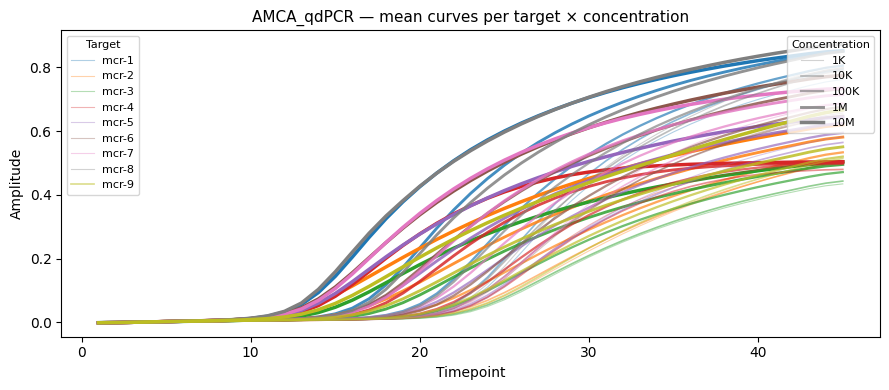

In [20]:
def plot_all_in_one(ori, labels, concentration, t_axis=None, title=''):
    """One mean curve per (target, concentration) group.
    Same target → same colour; concentration → linestyle / line width graduation.
    """
    valid = ~np.isnan(concentration)
    ori_v, lbl_v, con_v = ori[valid], labels[valid], concentration[valid]
    if t_axis is None:
        t_axis = np.arange(ori.shape[1])

    unique_tgt  = sorted(np.unique(lbl_v))
    unique_conc = sorted(np.unique(con_v))

    # Map concentration rank → line width & alpha (low conc = thinner/lighter)
    n_c = len(unique_conc)
    lw_range  = np.linspace(0.8, 2.5, n_c)
    alp_range = np.linspace(0.35, 1.0, n_c)
    conc_rank = {c: i for i, c in enumerate(unique_conc)}

    fig, ax = plt.subplots(figsize=(9, 4))

    handles_tgt  = {}
    handles_conc = {}

    for tgt in unique_tgt:
        color = TARGET_COLORS.get(tgt, 'gray')
        for c_val in unique_conc:
            mask = (lbl_v == tgt) & (con_v == c_val)
            if mask.sum() == 0: continue
            rank = conc_rank[c_val]
            mean_curve = ori_v[mask].mean(axis=0)
            line, = ax.plot(t_axis, mean_curve, color=color,
                            linewidth=lw_range[rank], alpha=alp_range[rank])
            if tgt not in handles_tgt:
                handles_tgt[tgt] = line
            if c_val not in handles_conc:
                handles_conc[c_val] = line

    # Legend: targets (colour) + concentrations (weight)
    leg1 = ax.legend(
        handles=list(handles_tgt.values()), labels=list(handles_tgt.keys()),
        title='Target', loc='upper left', fontsize=8, title_fontsize=8
    )
    import matplotlib.lines as mlines
    conc_handles = [
        mlines.Line2D([], [], color='gray', linewidth=lw_range[conc_rank[c]], alpha=alp_range[conc_rank[c]],
                      label=_conc_label(c))
        for c in unique_conc
    ]
    ax.add_artist(leg1)
    ax.legend(handles=conc_handles, title='Concentration', loc='upper right', fontsize=8, title_fontsize=8)

    ax.set_title(f'{title} — mean curves per target × concentration', fontsize=11)
    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Amplitude')
    plt.tight_layout()
    plt.show()


plot_all_in_one(ori, labels, conc, t_axis, title=FOLDER)

---
## Section 4 · Exploratory analysis

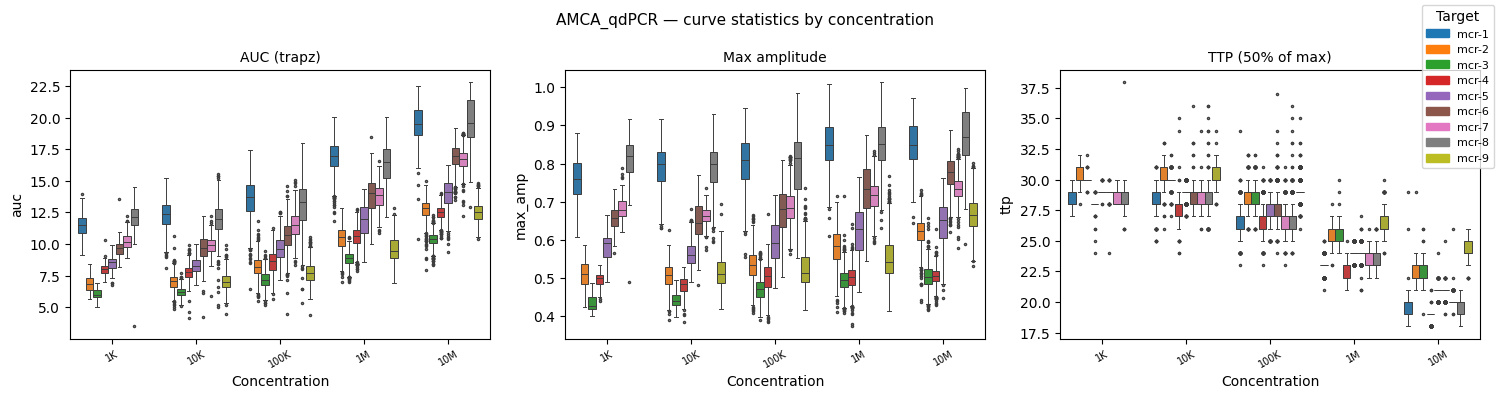

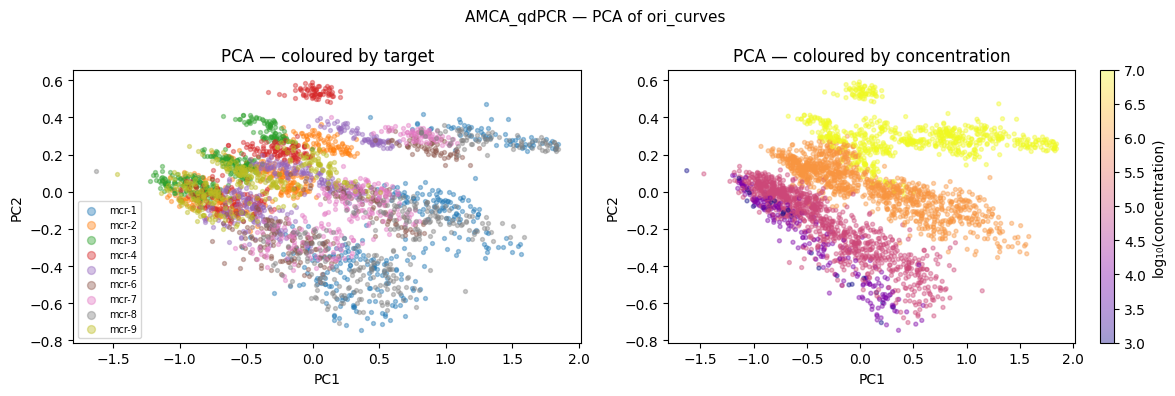

In [21]:
def compute_curve_stats(ori, labels, concentration):
    """Per-curve: AUC (trapz), max amplitude, TTP (first index above 50% of max).
    Returns a DataFrame with columns: target, concentration, auc, max_amp, ttp.
    """
    rows = []
    T = ori.shape[1]
    for i in range(len(ori)):
        curve = ori[i]
        auc   = np.trapz(curve)
        mx    = curve.max()
        above = np.where(curve >= 0.5 * mx)[0]
        ttp   = above[0] if len(above) > 0 else T
        rows.append(dict(
            target=labels[i],
            concentration=concentration[i],
            conc_label=_conc_label(concentration[i]) if not np.isnan(concentration[i]) else 'NaN',
            auc=auc,
            max_amp=mx,
            ttp=ttp,
        ))
    df = pd.DataFrame(rows)
    df = df[~np.isnan(df['concentration'])]   # drop NaN concentration rows
    return df


def plot_curve_stats(stats_df, title=''):
    """Boxplots of AUC, max amplitude, and TTP per target × concentration."""
    metrics = [('auc', 'AUC (trapz)'), ('max_amp', 'Max amplitude'), ('ttp', 'TTP (50% of max)')]
    unique_tgt = sorted(stats_df['target'].unique())
    palette = {t: TARGET_COLORS.get(t, 'gray') for t in unique_tgt}

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))

    # Sort concentrations numerically for x-axis
    conc_order = [_conc_label(c) for c in sorted(stats_df['concentration'].unique())]

    for ax, (col, label) in zip(axes, metrics):
        sns.boxplot(data=stats_df, x='conc_label', y=col, hue='target',
                    order=conc_order, palette=palette, ax=ax,
                    linewidth=0.7, fliersize=1.5)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('Concentration')
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.get_legend().remove()

    # Shared legend
    handles = [plt.Rectangle((0,0),1,1, color=palette[t]) for t in unique_tgt]
    fig.legend(handles, unique_tgt, title='Target', loc='upper right', fontsize=8)
    fig.suptitle(f'{title} — curve statistics by concentration', fontsize=11)
    plt.tight_layout()
    plt.show()


def plot_pca(ori, labels, concentration, t_axis=None, title='', n_subsample=3000):
    """PCA of raw curves. Colour = target, marker size ∝ log(concentration)."""
    valid = ~np.isnan(concentration)
    ori_v, lbl_v, con_v = ori[valid], labels[valid], concentration[valid]

    # Subsample if large
    if len(ori_v) > n_subsample:
        idx = np.random.choice(len(ori_v), n_subsample, replace=False)
        ori_v, lbl_v, con_v = ori_v[idx], lbl_v[idx], con_v[idx]

    pcs = PCA(n_components=2).fit_transform(ori_v)

    # Normalise concentration to marker size [20, 120]
    log_c  = np.log10(np.maximum(con_v, 1))
    s_norm = 20 + 100 * (log_c - log_c.min()) / (log_c.max() - log_c.min() + 1e-8)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: colour by target
    for tgt in sorted(np.unique(lbl_v)):
        m = lbl_v == tgt
        axes[0].scatter(pcs[m, 0], pcs[m, 1], c=[TARGET_COLORS.get(tgt, 'gray')],
                        s=8, alpha=0.4, label=tgt, rasterized=True)
    axes[0].set_title('PCA — coloured by target')
    axes[0].legend(fontsize=7, markerscale=2)

    # Right: colour by log concentration
    sc = axes[1].scatter(pcs[:, 0], pcs[:, 1], c=np.log10(con_v),
                         cmap='plasma', s=8, alpha=0.4, rasterized=True)
    plt.colorbar(sc, ax=axes[1], label='log₁₀(concentration)')
    axes[1].set_title('PCA — coloured by concentration')

    for ax in axes:
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')

    fig.suptitle(f'{title} — PCA of ori_curves', fontsize=11)
    plt.tight_layout()
    plt.show()


stats = compute_curve_stats(ori, labels, conc)
plot_curve_stats(stats, FOLDER)
plot_pca(ori, labels, conc, t_axis, FOLDER)

---
## Section 5 · Misclassification by concentration

Loads saved classification results and reconstructs per-sample fold assignments to link each test prediction back to its concentration value.

In [22]:
def load_results(folder, lab_folder=LAB_FOLDER, result_jl=RESULT_JL):
    """Load classification_performances.joblib for *folder*.
    Returns the inner results dict for the first available curve_type key,
    or None if the file does not exist.
    """
    p = Path(lab_folder) / folder / result_jl
    if not p.exists():
        print(f'[!] Results not found: {p}')
        return None
    return joblib.load(p)


def _get_res_entry(all_results, outlier_filter=None):
    """Navigate the nested results dict to the per-filter entry.
    
    Structure: all_results[curve_type_key][mode_key][outlier_filter]
    Returns (res_entry, curve_type_key, mode_key) or (None, None, None).
    """
    for ct_key, ct_val in all_results.items():
        if not isinstance(ct_val, dict): continue
        for mode_key, mode_val in ct_val.items():
            if not isinstance(mode_val, dict): continue
            if outlier_filter in mode_val:
                return mode_val[outlier_filter], ct_key, mode_key
    return None, None, None


def _reconstruct_fold_conc(labels, concentration, n_splits=N_SPLITS, outlier_filter=None, features_df=None):
    """Reconstruct test-fold sample indices using the same StratifiedKFold used during training.
    
    Returns list of concentration arrays (one per fold), aligned with y_trues_ / y_preds_.
    """
    # Apply outlier filter mask
    if outlier_filter is not None and features_df is not None and outlier_filter in features_df.columns:
        mask = (features_df[outlier_filter] == 1).fillna(False).values
    else:
        mask = np.ones(len(labels), dtype=bool)

    lbl_f = labels[mask]
    con_f = concentration[mask]

    le = LabelEncoder()
    y_enc = le.fit_transform(lbl_f)

    min_class = np.unique(y_enc, return_counts=True)[1].min()
    actual_splits = min(n_splits, min_class)

    splitter = StratifiedKFold(n_splits=actual_splits, shuffle=True, random_state=0)
    fold_concs = []
    fold_labels = []
    for _, test_idx in splitter.split(np.zeros(len(y_enc)), y_enc):
        fold_concs.append(con_f[test_idx])
        fold_labels.append(le.inverse_transform(y_enc[test_idx]))
    return fold_concs, fold_labels, le


def build_prediction_df(res_entry, model_key, fold_concs, fold_labels, le):
    """Concatenate per-fold predictions into a single DataFrame with concentration.
    Columns: true_label, pred_label, concentration, correct.
    """
    pred_key = f'y_preds_{model_key}_'
    if pred_key not in res_entry:
        # Try config lookup
        for pk, _, _ in [config.MODEL_KEY_MAP.get(model_key, (None,)*3)]:
            if pk and pk in res_entry:
                pred_key = pk
                break
        else:
            print(f'[!] Key {pred_key!r} not found in results. Available: {[k for k in res_entry if "preds" in k][:6]}')
            return None

    rows = []
    n_folds = min(len(res_entry['y_trues_']), len(fold_concs))
    for fi in range(n_folds):
        y_true = res_entry['y_trues_'][fi]
        y_pred = res_entry[pred_key][fi]
        conc_f = fold_concs[fi]
        lbl_f  = fold_labels[fi]

        # Decode integer labels → strings if needed
        if isinstance(y_true[0], (int, np.integer)):
            true_strs = le.inverse_transform(y_true)
            pred_strs = le.inverse_transform(y_pred)
        else:
            true_strs, pred_strs = np.array(y_true), np.array(y_pred)

        for j in range(min(len(true_strs), len(conc_f))):
            rows.append(dict(
                true_label=true_strs[j],
                pred_label=pred_strs[j],
                concentration=conc_f[j],
                correct=(true_strs[j] == pred_strs[j]),
                fold=fi,
            ))
    return pd.DataFrame(rows)


def plot_misclassification_by_concentration(
        pred_df, title='', model_key=''):
    """Two panels:
    Left  — accuracy per target × concentration (line plot).
    Right — confusion matrix where rows = (target, conc) and cols = predicted target.
    """
    if pred_df is None or pred_df.empty:
        print('[!] No prediction data available.'); return

    valid = pred_df[~np.isnan(pred_df['concentration'])].copy()
    valid['conc_label'] = valid['concentration'].map(_conc_label)
    unique_tgt  = sorted(valid['true_label'].unique())
    unique_conc = sorted(valid['concentration'].unique())
    conc_lbls   = [_conc_label(c) for c in unique_conc]

    # ── Panel 1: accuracy per target × concentration ──────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    for tgt in unique_tgt:
        accs = []
        for c in unique_conc:
            sub = valid[(valid['true_label'] == tgt) & (valid['concentration'] == c)]
            accs.append(sub['correct'].mean() if len(sub) > 0 else np.nan)
        color = TARGET_COLORS.get(tgt, 'gray')
        ax.plot(conc_lbls, accs, marker='o', color=color, label=tgt, linewidth=1.5)

    ax.set_xlabel('Concentration')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title('Accuracy per target × concentration')
    ax.legend(fontsize=8, title='Target')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.axhline(1 / len(unique_tgt), color='gray', linestyle='--', linewidth=0.8, label='Chance')
    ax.grid(axis='y', alpha=0.3)

    # ── Panel 2: extended confusion matrix ────────────────────────────────────
    ax = axes[1]
    row_labels = [(tgt, _conc_label(c)) for tgt in unique_tgt for c in unique_conc]
    col_labels = unique_tgt

    mat = np.zeros((len(row_labels), len(col_labels)))
    for ri, (tgt, clbl) in enumerate(row_labels):
        sub = valid[(valid['true_label'] == tgt) & (valid['conc_label'] == clbl)]
        if len(sub) == 0: continue
        for ci, pred_tgt in enumerate(col_labels):
            mat[ri, ci] = (sub['pred_label'] == pred_tgt).sum() / len(sub)

    im = ax.imshow(mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Fraction')

    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels([f'{t} / {c}' for t, c in row_labels], fontsize=6)
    ax.set_xlabel('Predicted target')
    ax.set_ylabel('True (target / concentration)')
    ax.set_title('Confusion: true(target,conc) → predicted target')

    # Diagonal markers for correct cells
    for ri, (tgt, _) in enumerate(row_labels):
        if tgt in col_labels:
            ci = col_labels.index(tgt)
            ax.add_patch(plt.Rectangle((ci - 0.5, ri - 0.5), 1, 1,
                                        fill=False, edgecolor='black', lw=0.8))

    fig.suptitle(f'{title} — {model_key} misclassification by concentration', fontsize=11)
    plt.tight_layout()
    plt.show()

In [23]:
all_results = load_results(FOLDER)

if all_results is not None:
    res_entry, ct_key, mode_key = _get_res_entry(all_results, OUTLIER_FILTER)
    if res_entry is None:
        print(f'[!] No entry for filter={OUTLIER_FILTER!r}. Available filters:')
        for ct, ct_v in all_results.items():
            if isinstance(ct_v, dict):
                for mk, mv in ct_v.items():
                    if isinstance(mv, dict):
                        print(f'  [{ct}][{mk}]: {list(mv.keys())}')
    else:
        print(f'Using results: curve_type={ct_key!r}, mode={mode_key!r}, filter={OUTLIER_FILTER!r}')
        fold_concs, fold_labels, le = _reconstruct_fold_conc(labels, conc, N_SPLITS, OUTLIER_FILTER)
        print(f'Reconstructed {len(fold_concs)} folds')
        pred_df = build_prediction_df(res_entry, MODEL_KEY, fold_concs, fold_labels, le)
        if pred_df is not None:
            print(f'Prediction df: {len(pred_df)} rows, overall accuracy: {pred_df["correct"].mean():.3f}')
            plot_misclassification_by_concentration(pred_df, FOLDER, MODEL_KEY)

[!] Results not found: /vol/bitbucket/gk225/POC_DDM_datasets/LAB_DDM_paper/AMCA_qdPCR/classification_performances.joblib


---
## Section 6 · Kinetic feature correlation

In [24]:
def _kinetic_feature_cols(kf_df):
    """Return only the true kinetic feature columns, dropping outlier-filter flags."""
    exclude_keywords = ('label', 'knn_top', 'msc_', 'amf_', 'cnn_ae_', 'lstm_ae_')
    return [c for c in kf_df.select_dtypes(include='number').columns
            if not any(k in c for k in exclude_keywords)]


def plot_kinetic_feature_correlations(kf_df, labels, concentration,
                                      group_by='concentration',
                                      top_n=12, title=''):
    """Visualise the relationship between kinetic features and concentration or target.

    group_by='concentration' : ranks features by |Pearson r| with log10(concentration).
    group_by='target'        : ranks features by one-way ANOVA F-statistic across targets.

    Two panels are shown:
      Left  — horizontal bar chart of the top_n ranked features.
      Right — violin/strip grid for the top 6 of those features.
    """
    from scipy import stats as sps

    valid = ~np.isnan(concentration)
    kf_v   = kf_df.loc[valid].reset_index(drop=True)
    lbl_v  = labels[valid]
    con_v  = concentration[valid]
    log_c  = np.log10(con_v)

    feat_cols = _kinetic_feature_cols(kf_v)
    kf_vals   = kf_v[feat_cols].copy()

    # ── Rank features ─────────────────────────────────────────────────────────
    scores = {}
    if group_by == 'concentration':
        for col in feat_cols:
            x = kf_vals[col].values
            m = np.isfinite(x) & np.isfinite(log_c)
            if m.sum() < 10: continue
            r, _ = sps.pearsonr(x[m], log_c[m])
            scores[col] = r                          # keep sign for direction
        score_label = 'Pearson r  (feature vs log₁₀ conc)'
        sorted_feats = sorted(scores, key=lambda c: abs(scores[c]), reverse=True)[:top_n]

    else:  # group_by == 'target'
        unique_tgt = np.unique(lbl_v)
        for col in feat_cols:
            groups = [kf_vals.loc[lbl_v == t, col].dropna().values for t in unique_tgt]
            groups = [g for g in groups if len(g) >= 3]
            if len(groups) < 2: continue
            f, _ = sps.f_oneway(*groups)
            scores[col] = f
        score_label = 'ANOVA F-statistic  (feature vs target)'
        sorted_feats = sorted(scores, key=lambda c: scores[c], reverse=True)[:top_n]

    # ── Panel 1: ranked bar chart ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, top_n * 0.38 + 1)),
                              gridspec_kw={'width_ratios': [1, 1.8]})

    vals  = [scores[f] for f in sorted_feats]
    colors_bar = ['#d62728' if v < 0 else '#1f77b4' for v in vals]
    axes[0].barh(range(len(sorted_feats)), vals, color=colors_bar, alpha=0.8)
    axes[0].set_yticks(range(len(sorted_feats)))
    axes[0].set_yticklabels(sorted_feats, fontsize=8)
    axes[0].invert_yaxis()
    axes[0].axvline(0, color='black', linewidth=0.8)
    axes[0].set_xlabel(score_label, fontsize=8)
    axes[0].set_title(f'Top {top_n} features', fontsize=10)
    axes[0].grid(axis='x', alpha=0.3)

    # ── Panel 2: violin/scatter for top 6 ─────────────────────────────────────
    show_feats = sorted_feats[:6]
    n_show = len(show_feats)
    ax2 = axes[1]
    ax2.axis('off')
    sub_fig, sub_axes = plt.subplots(2, 3, figsize=(12, 6))
    sub_axes = sub_axes.flatten()

    for i, feat in enumerate(show_feats):
        ax = sub_axes[i]
        feat_vals = kf_v[feat].values

        if group_by == 'concentration':
            unique_conc = sorted(np.unique(con_v))
            groups_data = [feat_vals[(con_v == c) & np.isfinite(feat_vals)] for c in unique_conc]
            ax.violinplot(groups_data, positions=range(len(unique_conc)), showmedians=True)
            ax.set_xticks(range(len(unique_conc)))
            ax.set_xticklabels([_conc_label(c) for c in unique_conc], rotation=30, fontsize=6)
            ax.set_title(f'{feat}\nr={scores[feat]:.2f}', fontsize=7)

        else:
            unique_tgt = sorted(np.unique(lbl_v))
            groups_data = [feat_vals[lbl_v == t] for t in unique_tgt]
            parts = ax.violinplot(groups_data, positions=range(len(unique_tgt)), showmedians=True)
            for j, pc in enumerate(parts['bodies']):
                tgt = unique_tgt[j]
                pc.set_facecolor(TARGET_COLORS.get(tgt, 'steelblue'))
                pc.set_alpha(0.7)
            ax.set_xticks(range(len(unique_tgt)))
            ax.set_xticklabels(unique_tgt, rotation=30, fontsize=6)
            ax.set_title(f'{feat}\nF={scores[feat]:.1f}', fontsize=7)

        ax.set_ylabel(feat, fontsize=6)
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(labelsize=6)

    for i in range(n_show, len(sub_axes)):
        sub_axes[i].axis('off')

    sub_fig.suptitle(f'{title} — top feature distributions by {group_by}', fontsize=10)
    sub_fig.tight_layout()

    plt.figure(fig.number)
    fig.suptitle(f'{title} — kinetic feature correlation with {group_by}', fontsize=11)
    axes[0].figure.tight_layout()
    plt.show()
    plt.figure(sub_fig.number)
    plt.show()

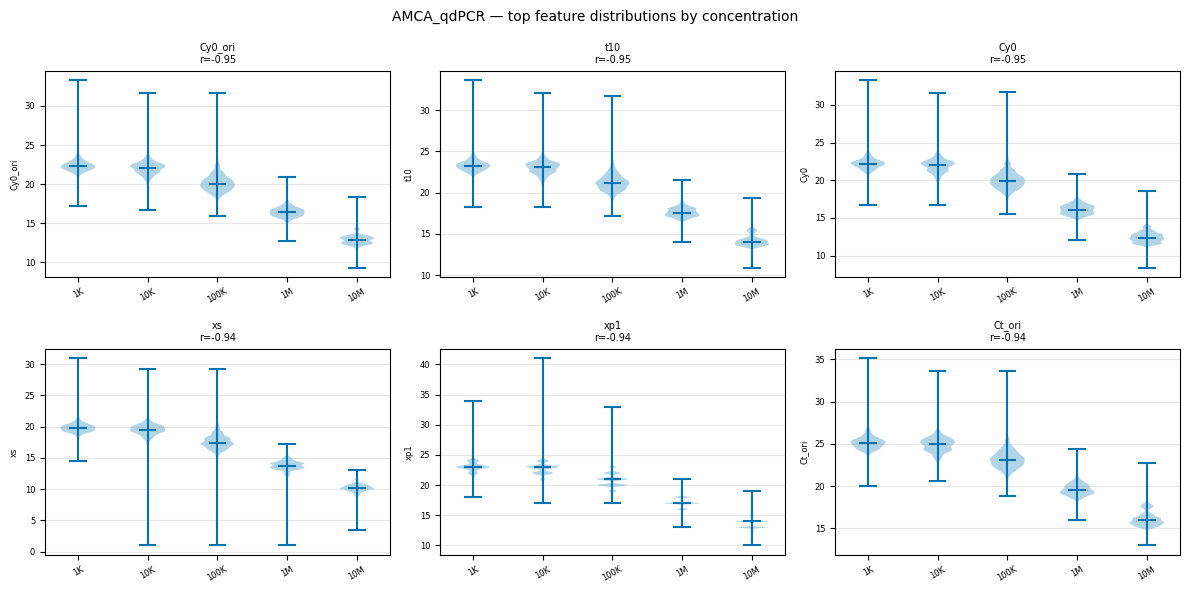

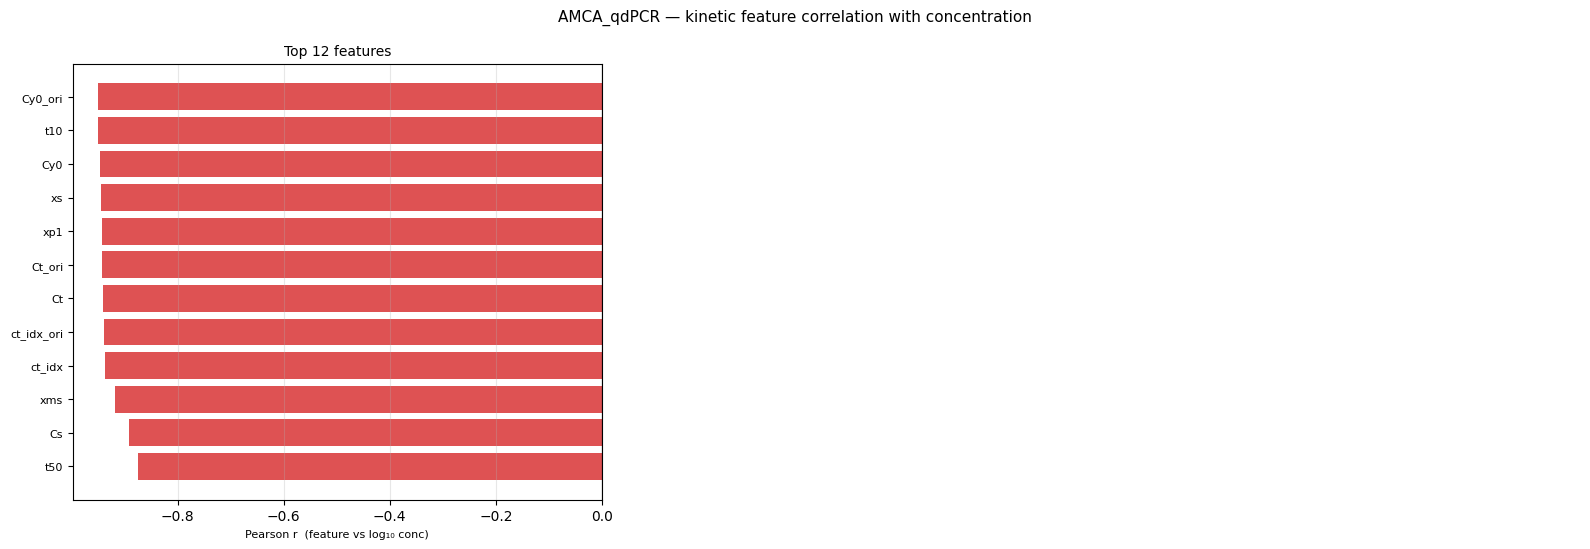

<Figure size 640x480 with 0 Axes>

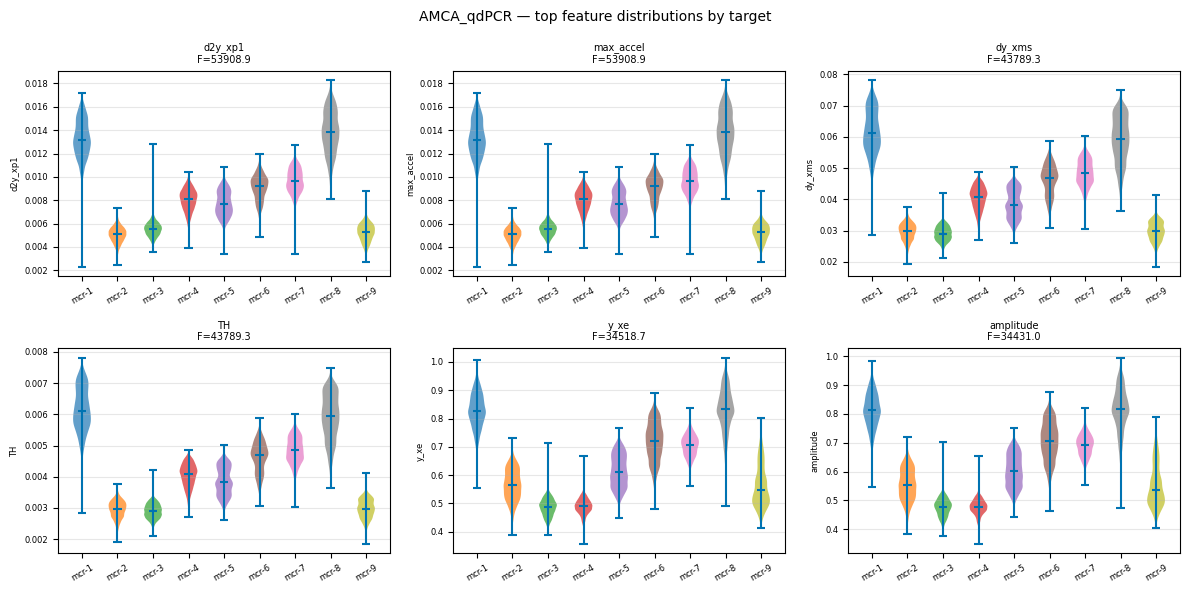

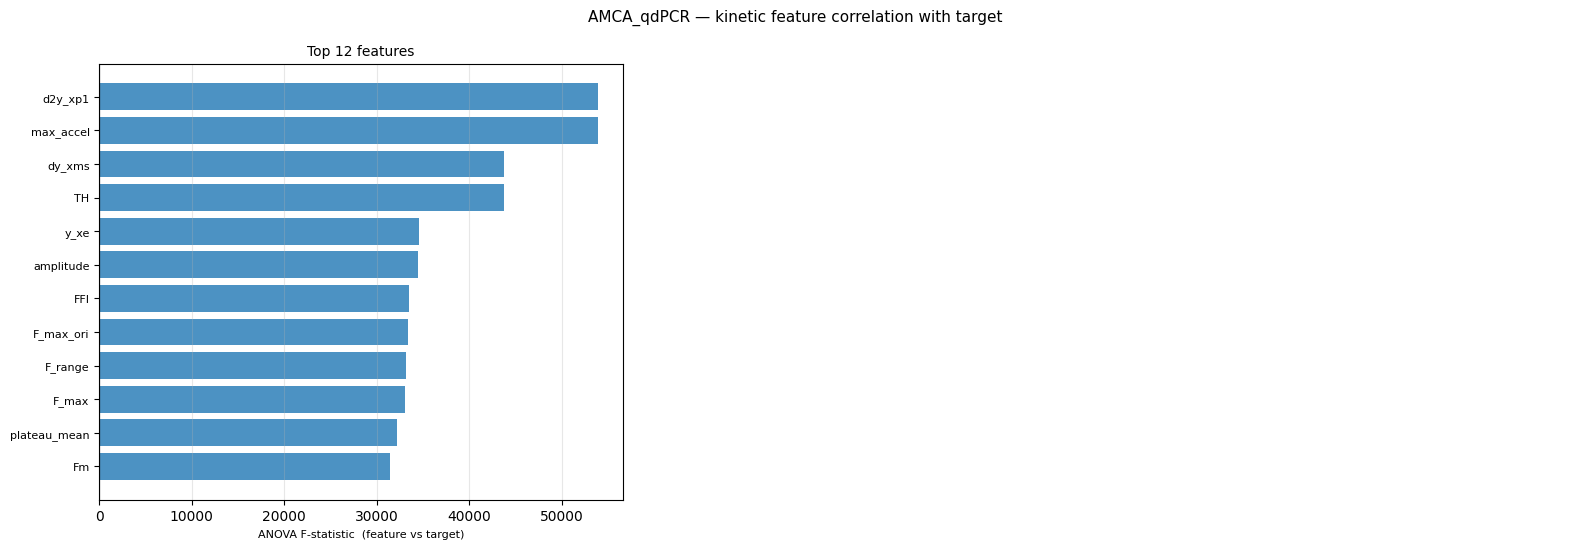

<Figure size 640x480 with 0 Axes>

In [25]:
if kf is not None:
    plot_kinetic_feature_correlations(kf, labels, conc, group_by='concentration', title=FOLDER)
    plot_kinetic_feature_correlations(kf, labels, conc, group_by='target', title=FOLDER)
else:
    print('[!] No kinetic features found in this joblib.')

---
## (Optional) Multi-folder comparison

Uncomment and run to iterate over all concentration-having folders.

In [26]:
# available = list_available_folders()['folder'].tolist()
# for folder in available:
#     print(f"\n{'='*60}\n{folder}\n{'='*60}")
#     d = load_folder_data(folder)
#     _assign_target_colors(d['labels'])
#     plot_distribution_table(d['labels'], d['concentration'], folder)
#     plot_all_in_one(d['ori_curves'], d['labels'], d['concentration'],
#                     d['timestamps'], title=folder)